## Load modules

In [1]:
!module load scipy-stack/2023b
!module list


Currently Loaded Modules:
  1) CCconfig              10) openmpi/4.1.5                (m)
  2) gentoo/2023      (S)  11) flexiblas/3.3.1
  3) gcccore/.12.3    (H)  12) blis/0.9.0
  4) gcc/12.3         (t)  13) StdEnv/2023                  (S)
  5) hwloc/2.9.1           14) mii/1.1.2
  6) ucx/1.14.1            15) python/3.11 -> python/3.11.5 (t)
  7) libfabric/1.18.0      16) ipykernel/2023b
  8) pmix/4.2.4            17) ipython-kernel/3.11          (S)
  9) ucc/1.2.0             18) scipy-stack/2023b            (math)

  Where:
   S:     Module is Sticky, requires --force to unload or purge
   m:     MPI implementations / Implémentations MPI
   math:  Mathematical libraries / Bibliothèques mathématiques
   t:     Tools for development / Outils de développement
   H:                Hidden Module

 



In [3]:
import numpy as np
import pandas as pd
import math as math
import matplotlib.pyplot as plt
import subprocess
import os
import scipy.stats as stats
import seaborn as sns
from collections import Counter
from tqdm import tqdm
import glob

## Get the number of raw reads for each file and prepare directories

In [8]:
#Load datasheet
input_datasheet = pd.read_csv('../ChrR_datasheet.csv', sep=',', index_col=0)
input_datasheet

,strain,timepoint,condition,replicate,raw_reads
sample,,,,,
A1,SC5314,TP0,YPD,1,10277358
A2,SC5314,TP0,YPD,2,10567735
A3,SC5314,TP0,YPD,3,10837769
A4,SC5314,TP0,YPD,4,13860937
B1,SC5314,TP3,YPD,1,12439584
B2,SC5314,TP3,YPD,2,10844845
B3,SC5314,TP3,YPD,3,14845423
B4,SC5314,TP3,YPD,4,13560101
C1,SC5314,TP3,Low_FLZ,1,12468523


In [ ]:
raw_read_count_dict = {}

for sample in input_datasheet.index:
    #Look specifically for R1 FASTQ files
    files = glob.glob(f"../data/{sample}*_R1*.fastq.gz")
    if files:
        fastq = files[0]  # choose the first matching R1 file
        count = subprocess.check_output(f"zgrep -o '@L' {fastq} | wc -l", shell=True, text=True)
        raw_read_count_dict[sample] = int(count.strip())
    else:
        raw_read_count_dict[sample] = 0  # no R1 file found

input_datasheet['raw_reads'] = pd.Series(raw_read_count_dict)
input_datasheet.to_csv('../ChrR_datasheet.csv', sep=',')

In [14]:
sum(raw_read_count_dict.values())
#total number of reads sequenced

191971616

,strain,timepoint,condition,replicate,raw_reads
sample,,,,,
A1,SC5314,TP0,YPD,1,10277358
A2,SC5314,TP0,YPD,2,10567735
A3,SC5314,TP0,YPD,3,10837769
A4,SC5314,TP0,YPD,4,13860937
B1,SC5314,TP3,YPD,1,12439584
B2,SC5314,TP3,YPD,2,10844845
B3,SC5314,TP3,YPD,3,14845423
B4,SC5314,TP3,YPD,4,13560101
C1,SC5314,TP3,Low_FLZ,1,12468523


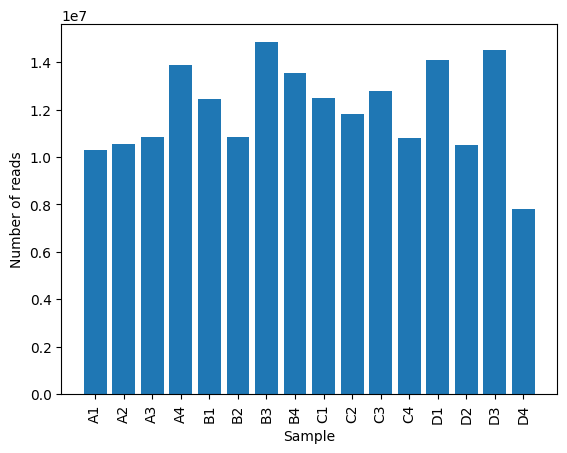

In [17]:
plt.bar([x for x in input_datasheet.index], [input_datasheet.at[x, 'raw_reads'] for x in input_datasheet.index])
plt.xlabel('Sample')
plt.ylabel('Number of reads')
#This just makes the labels on the x-axis vertical (rather than horizontal where they would probably overlap and not be readable)
plt.xticks(rotation=90);

input_datasheet

In [18]:
#Create directories
list_dir = os.listdir()

if 'logs' not in list_dir:
    os.mkdir('logs')
if 'fastqc_outputs' not in list_dir:
    os.mkdir('fastqc_outputs')
if 'pear_output' not in list_dir:
    os.mkdir('pear_output')
if 'vsearch_trim' not in list_dir:
    os.mkdir('vsearch_trim')
if 'vsearch_aggregate' not in list_dir:
    os.mkdir('vsearch_aggregate')

## Run FastQC on samples
Change the time as a function of the number of reads. It should only take like 10 minutes. Run with sbatch run_fastqc.sh.

In [ ]:
#Number of samples
n_files = len(input_datasheet.index)  #This should already be defined before this block

with open('./run_fastqc.sh', 'w') as dest:

    dest.write('#!/bin/bash\n')
    dest.write('#SBATCH --nodes=1\n')
    dest.write('#SBATCH --ntasks-per-node=1\n')
    dest.write('#SBATCH --account=your-account\n')
    dest.write(f'#SBATCH --cpus-per-task={n_files + 1}\n')
    dest.write(f'#SBATCH --mem={math.ceil((n_files + 1) * 0.5)}G\n')
    dest.write('#SBATCH --time=0-03:30:00\n')
    dest.write('#SBATCH --output=logs/slurm-%j.out\n')
    dest.write('#SBATCH --mail-type=ALL\n')
    dest.write('#SBATCH --job-name=fastqc\n')
    dest.write('\n')
    
    dest.write('module load fastqc\n')
    dest.write('\n')
    
    #FastQC command now outputs into current working directory: ./fastqc_outputs
    fastqc_command = f'fastqc --outdir fastqc_outputs -t {n_files} --extract --delete ../data/*.fastq.gz'
    dest.write(fastqc_command)

## Trim and merge reads
Change the time as a function of the number of reads. For my ChrR library, it did everything in about 1.5h. Run with sbatch process_barcodes.sh

In [27]:
with open('./process_barcodes.sh', 'w') as dest:
    dest.write('#!/bin/bash\n')
    dest.write('#SBATCH --account=your-account\n')
    dest.write('#SBATCH --nodes=1\n')
    dest.write('#SBATCH --ntasks-per-node=1\n')
    dest.write('#SBATCH --cpus-per-task=16\n')  
    dest.write('#SBATCH --mem=5G\n')
    dest.write('#SBATCH --time=0-24:00:00\n')
    dest.write('#SBATCH --output=logs/slurm-%j.out\n')
    dest.write('#SBATCH --mail-type=ALL\n')
    dest.write('#SBATCH --job-name=merging\n')
    dest.write('\n')

    #Load software modules
    dest.write('module load StdEnv/2020\n')
    dest.write('module load pear\n')
    dest.write('module load vsearch\n\n')

    #Loop through each sample in the input_datasheet
    for sample in input_datasheet.index:
        dest.write('date\n')

        #FASTQ paths (R1 and R2)
        fastq_R1 = f'../data/{sample}_R1_001.fastq.gz'
        fastq_R2 = f'../data/{sample}_R2_001.fastq.gz'

        #Output file paths
        initial_trim_R1_out = f'./vsearch_trim/{sample}_R1_initial_trimmed.fastq'
        initial_trim_R2_out = f'./vsearch_trim/{sample}_R2_initial_trimmed.fastq'
        pear_out = f'./pear_output/{sample}'
        assembled_reads = f'./pear_output/{sample}.assembled.fastq'
        filter_out = f'./vsearch_trim/{sample}_final_trimmed.fastq'
        filter_rc = f'./vsearch_trim/{sample}_final_trimmed_rc.fastq'
        aggregate_fasta = f'./vsearch_aggregate/{sample}_aggregate.fasta'

        #Command definitions
        initial_trim_R1 = f'vsearch --fastx_filter {fastq_R1} --fastq_stripleft 2 --fastq_stripright 2 --fastqout {initial_trim_R1_out}\n'
        initial_trim_R2 = f'vsearch --fastx_filter {fastq_R2} --fastq_stripleft 2 --fastq_stripright 2 --fastqout {initial_trim_R2_out}\n'
       
        pear_command = f'pear -f {initial_trim_R1_out} -r {initial_trim_R2_out} -o {pear_out} -j 16 -u 0.05 -q 20 -m 180 -n 20\n'
        #-f defines the forward reads file, -r defines the reverse reads file, -o defines the output location
        #-j defines to use 16 threads for processing (should be the same as the CPUs requested at the top)
        #-u defines the maximum proportion allowed for unmerged base pairs. If trimming first, this is fine.
        #-q specifies the quality score threshold for trimming the low quality part of a read. If the quality scores of two consecutive bases are strictly less than the specified threshold, the rest of the read will be trimmed.
        #-m maximum possible length of the assembled sequences, -n minimum possible length of the assembled sequences
       
        filter_command = f'vsearch --fastx_filter {assembled_reads} --fastq_stripleft 1 --fastq_stripright 1 --fastaout {filter_out}\n'
        #fastq_stripleft defines the position to trim from the 5' end, vice versa for fastq_stripright
        
        rc_command = f'vsearch --fastx_revcomp {filter_out} --fastaout {filter_rc}\n'
        #creates the reverse complement of the trimmed sequences
       
        aggregate_command = f'vsearch --derep_fulllength {filter_rc} --relabel seq --output {aggregate_fasta} --sizeout\n'
        #derep_fulllength removes duplicate sequences (and through this, counts how many times a sequence was duplicated, listing that numnber next to the sequence in question)

        #writes all of the variables to the output file in this order (ie. performs the jobs in this order)
        #These can be switched around. For example, you could switch them around to have trimming done first or merging done first.
        dest.write(initial_trim_R1) #first trim of F reads
        dest.write(initial_trim_R2) #first trim of R reads
        dest.write('date\n') #lists the time/date for logs
        dest.write(pear_command) #aligning and merging program
        dest.write('date\n') #lists the time/date for logs
        dest.write(filter_command) #second trimming program
        dest.write(rc_command) #creates the reverse complement of the trimmed sequences
        dest.write('date\n') #lists the time/date for logs
        dest.write(aggregate_command)
        dest.write('date\n') #lists the time/date for logs

    dest.write('date\n') #lists the time/date for logs

In [ ]:
#Load datasheet again if you closed the program and came back
input_datasheet = pd.read_csv('../ChrR_datasheet.csv', sep=',', index_col=0)
input_datasheet

In [9]:
assembled_read_count = {}

for sample in input_datasheet.index:
    assembled_reads = './pear_output/'+str(sample)+'.assembled.fastq'
    command = 'grep -o \'@L\' '+assembled_reads+' | wc -l' #make sure the lines in the assembled files actually begin with "@L"
    
    output  = subprocess.check_output(command, shell=True, text=True)
    assembled_read_count[sample] = int(output.strip('\n'))
    
input_datasheet['assembled_reads'] = pd.Series(assembled_read_count)
    
input_datasheet.to_csv('../ChrR_datasheet.csv', sep=',')

In [11]:
#This just updates the input_datasheet so that you don't have to run everything before this again every time you open up the code
input_datasheet = pd.read_csv('../ChrR_datasheet.csv', sep=',', index_col=0)
input_datasheet

,strain,timepoint,condition,replicate,raw_reads,assembled_reads
sample,,,,,,
A1,SC5314,TP0,YPD,1,10277358,10223857
A2,SC5314,TP0,YPD,2,10567735,10513473
A3,SC5314,TP0,YPD,3,10837769,10769662
A4,SC5314,TP0,YPD,4,13860937,13779968
B1,SC5314,TP3,YPD,1,12439584,12372752
B2,SC5314,TP3,YPD,2,10844845,10791416
B3,SC5314,TP3,YPD,3,14845423,14763394
B4,SC5314,TP3,YPD,4,13560101,13503607
C1,SC5314,TP3,Low_FLZ,1,12468523,12398106


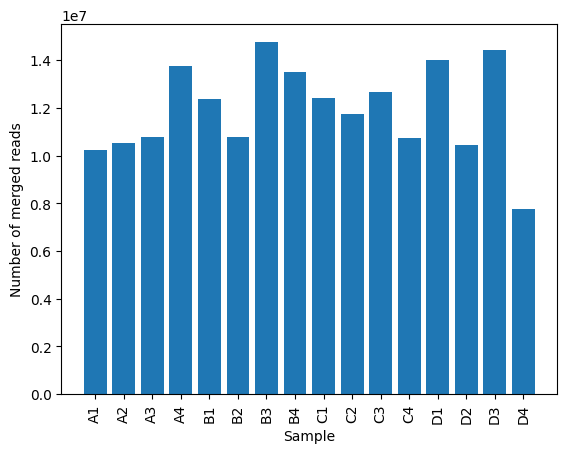

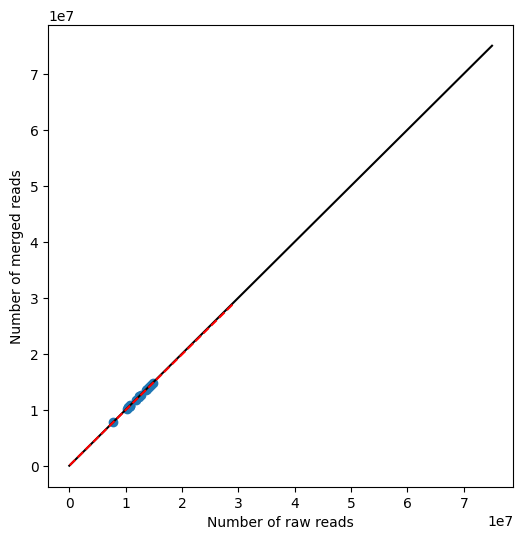

In [12]:
#Plotting the Merged Reads vs. Raw Reads
plt.bar([x for x in input_datasheet.index], [input_datasheet.at[x, 'assembled_reads'] for x in input_datasheet.index])
plt.xlabel('Sample')
plt.ylabel('Number of merged reads')
plt.xticks(rotation=90);

merge_stats = stats.linregress(input_datasheet.raw_reads, input_datasheet.assembled_reads)

plt.figure(figsize=(6,6))
plt.scatter(input_datasheet.raw_reads, input_datasheet.assembled_reads)

plt.plot([25000, 75000000], [25000, 75000000], '-k') #this is the black line, numbers in order are low x-pos of black line, high x-pos of black line, low y-pos of black line, high y-pos of black line

plt.xlabel('Number of raw reads')
plt.ylabel('Number of merged reads')

#this is the line of best fit (dotted red line). Make sure the values in the first range statement match those in the second range statement
plt.plot([x for x in range(100000, 29000000, 50000)], [(x*merge_stats[0])+merge_stats[1] for x in range(100000, 29000000, 50000)], 'r--')

## Count sgRNAs

In [13]:
#This reads your .CSV file called "sgrna_list.csv" that contains all of the sgRNAs, their sequences, and other info you want to store about them.
#The argument index_col=0 tells Pandas to use the first column as the index (i.e., row labels).
sgRNA_df = pd.read_csv('../sgrna_list.csv', index_col=0)

#This, as always, just prints the dataframe here in the notebook so you can see it.
sgRNA_df

,Alias,Gene,Barcode,Position
Number,,,,
1,CR07390CA_242,CR07390C_A,TGCGCACAATTTCCTGCACA,1605752.0
2,CR07390CA_276_revcom,CR07390C_A,GAGTATAGTGATCCATGTGC,1605740.0
3,CR07390CA_239_revcom,CR07390C_A,GCTATAACGTTACTAGTAGT,1605777.0
4,CR07390CA_140_revcom,CR07390C_A,ATAGATGTGATTGTCTTATA,1605876.0
5,CR07390CA_212_revcom,CR07390C_A,TCCATCATCATTATTACAAT,1605804.0
...,...,...,...,...
5697,non-targeting57,non-targeting57,TCCCCAAGGCTGTCCCCCAA,NaN
5698,non-targeting58,non-targeting58,GACCTCTTTCGACTAGGCCA,NaN
5699,non-targeting59,non-targeting59,GCACTAGCGTCCCACGAATG,NaN


In [14]:
#sgRNA_df.columns gives the list of column names in the DataFrame. list(sgRNA_df.columns) converts that into a regular Python list, which is stored in the new variable non_raw_cols.
non_raw_cols = list(sgRNA_df.columns)

#If that doesn't make sense, this is what the list contains. Since index_col=0 was specified when loading the CSV, the first column ("Number") is used as the index rather than being included in sgRNA_df.columns.
print(non_raw_cols)

['Alias', 'Gene', 'Barcode', 'Position']


### Count sgRNAs using perfect match, with a 5nt anchor

Copy and paste the following code into a new .py file:

In [ ]:
import numpy as np
import pandas as pd
import math as math
import matplotlib.pyplot as plt
import subprocess
import os
import scipy.stats as stats
import seaborn as sns
from collections import Counter
from tqdm import tqdm

#Load inputs
input_datasheet = pd.read_csv('../ChrR_datasheet.csv', sep=',', index_col=0)
input_datasheet

sgRNA_df = pd.read_csv('../sgrna_list.csv', index_col=0)
non_raw_cols = list(sgRNA_df.columns)
def get_dict_of_seq(fasta_file):
    file_fasta_dict = {}
    with open(fasta_file, 'r') as fasta:    
        #Loop through each line in the aggregate FASTA files
        for line in fasta: 
            #Check if the line starts with '>', which means it's a sequence header
            if line.startswith('>') == True:    
                seq_info = line.strip('>').strip('\n').split('\t')[0]  
                file_fasta_dict[seq_info] = ''   
            #If the line is not a header (ie. does not start with ">", it must be part of the nucleotide sequence
            else:       
                file_fasta_dict[seq_info] += line.strip('\n')
    return file_fasta_dict

#This defines a function named count_barcodes_perfect_match that takes two dictionaries as inputs.
#fasta_seq_dict: A dictionary where keys are FASTA sequence headers (which contain sequence counts) and values are the actual nucleotide sequences. 
#barcode_dict: A dictionary where keys are known barcode (sgRNA) sequences, and values are the corresponding sgRNA names.
def count_barcodes_perfect_match(fasta_seq_dict, barcode_dict):
    sample_sgRNA_counter = Counter()
    for key in list(fasta_seq_dict.keys()): 
        seq_count = int(key.split(';size=')[1])
        n_match = 0
        barcode_ids = []              
        for barcode in list(barcode_dict.keys()):                    
            
            #This checks if the sgRNA barcode appears within the sequence, with the flanking regions:
            if "TTCGA"+barcode+"GTTTT" in fasta_seq_dict[key]:                           
                
                #If there is a perfect match, we add 1 to n_match, and the barcode is added to barcode_ids for debugging later (if needed).
                n_match+=1
                barcode_ids.append(barcode)
                
                #If more than one sgRNA matches in this sequence, a warning is printed. Each read should only contain one sgRNA sequence.
                if n_match > 1:
                    print(key, n_match, barcode_ids)                               
                
                #Finally, we add the seq_count (number of reads) to the Counter for this corresponding sgRNA we just checked. barcode_dict[barcode] provides the sgRNA's name.
                sample_sgRNA_counter[barcode_dict[barcode]] +=seq_count                      
            
            #Instead of using the usual anchor approach, this looks for the sequence found in the uncloned plasmid backbone in fasta_seq_dict[key].
            #Everything else is the same as in the original if statement above.
            elif barcode == 'TGAAGAGCCATTAATGCTCTTCC':
                if 'GGAAGAGCATTAATGGCTCTTCA' in fasta_seq_dict[key]:
                    n_match+=1
                    barcode_ids.append(barcode)
                    if n_match > 1:
                        print(key, n_match, barcode_ids)       
                    sample_sgRNA_counter[barcode_dict[barcode]] +=seq_count                   
        if n_match>1:
            print(key)                 
    return sample_sgRNA_counter

#An empty dictionary initialized to store the TOTAL number of usable reads for each SAMPLE. This will track the total number of counts for the sgRNAs in each sample.
usable_reads_dict = {}
barcode_dict = {}
for sgRNA in sgRNA_df.index:
    barcode = sgRNA_df.at[sgRNA, 'Barcode']
    barcode_dict[barcode] = sgRNA
for sample in tqdm(input_datasheet.index, desc="Counting samples"):       
    
    #Here, we define the path to the aggregate FASTA file for each sample. This is the file that finally contains the NGS sequence data for the current sample. 
    aggregate_fasta = './vsearch_aggregate/'+str(sample)+'_aggregate.fasta'   
    fasta_dict = get_dict_of_seq(aggregate_fasta) 
    
    #Count barcodes and update usable reads dictionary
    sgRNA_counter = count_barcodes_perfect_match(fasta_dict, barcode_dict)
    usable_reads_dict[sample] = sum(sgRNA_counter.values())     
    
    #Generate column names. 
    col_name = input_datasheet.at[sample, 'strain']+'_'
    col_name += input_datasheet.at[sample, 'timepoint']+'_'
    col_name += input_datasheet.at[sample, 'condition']+'_'
    col_name += str(input_datasheet.at[sample, 'replicate'])  

    #Add data to the sgRNA dataframe
    sgRNA_df[col_name] = pd.Series(sgRNA_counter)

#Save results to .csv
sgRNA_df.to_csv("../sgrna_list.csv")

Then, copy the following code into a new .sh file:

In [ ]:
#!/bin/bash
#SBATCH --account=your-account
#SBATCH --nodes=1
#SBATCH --ntasks-per-node=1
#SBATCH --cpus-per-task=16
#SBATCH --mem=5G
#SBATCH --time=0-15:00:00
#SBATCH --output=logs/slurm-%j.out
#SBATCH --mail-type=ALL
#SBATCH --job-name=counting

module load scipy-stack/2023b  

python counting_python.py

Then, submit the job to SLURM to run. Alternatively, you can run this same code by executing the following 3 cells in order. It can take a long time, though, so is easier to submit to SLURM. Either way, after you are done, proceed to "Plotting the Number of Counts"

### Checking the Number of Counts and Replacing NaN Values with 0

In [27]:
#Load datasheet once again
input_datasheet = pd.read_csv('../ChrR_datasheet.csv', sep=',', index_col=0)

#Re-import the sgRNA_df from the updated .csv file
sgRNA_df = pd.read_csv('../sgrna_list.csv', sep=',', index_col=0)
sgRNA_df

,Alias,Gene,Barcode,Position,SC5314_TP0_YPD_1,SC5314_TP0_YPD_2,SC5314_TP0_YPD_3,SC5314_TP0_YPD_4,SC5314_TP3_YPD_1,SC5314_TP3_YPD_2,SC5314_TP3_YPD_3,SC5314_TP3_YPD_4,SC5314_TP3_Low_FLZ_1,SC5314_TP3_Low_FLZ_2,SC5314_TP3_Low_FLZ_3,SC5314_TP3_Low_FLZ_4,SC5314_TP3_High_FLZ_1,SC5314_TP3_High_FLZ_2,SC5314_TP3_High_FLZ_3,SC5314_TP3_High_FLZ_4
Number,,,,,,,,,,,,,,,,,,,,
1,CR07390CA_242,CR07390C_A,TGCGCACAATTTCCTGCACA,1605752.0,1119.0,312.0,879.0,1900.0,NaN,NaN,NaN,87.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CR07390CA_276_revcom,CR07390C_A,GAGTATAGTGATCCATGTGC,1605740.0,2017.0,1006.0,956.0,2949.0,344.0,811.0,472.0,459.0,303.0,598.0,1319.0,165.0,232.0,302.0,NaN,466.0
3,CR07390CA_239_revcom,CR07390C_A,GCTATAACGTTACTAGTAGT,1605777.0,88867.0,86080.0,83323.0,116333.0,94225.0,81253.0,110503.0,107952.0,78991.0,66290.0,74728.0,75440.0,73300.0,50792.0,72423.0,40650.0
4,CR07390CA_140_revcom,CR07390C_A,ATAGATGTGATTGTCTTATA,1605876.0,1977.0,755.0,1625.0,3364.0,130.0,NaN,363.0,205.0,159.0,56.0,113.0,75.0,1.0,NaN,237.0,NaN
5,CR07390CA_212_revcom,CR07390C_A,TCCATCATCATTATTACAAT,1605804.0,1182.0,862.0,952.0,1604.0,1415.0,943.0,1441.0,1752.0,823.0,759.0,875.0,1034.0,2235.0,529.0,1748.0,486.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5697,non-targeting57,non-targeting57,TCCCCAAGGCTGTCCCCCAA,NaN,1437.0,926.0,1189.0,1853.0,1421.0,672.0,951.0,1631.0,1507.0,757.0,248.0,1264.0,623.0,600.0,550.0,582.0
5698,non-targeting58,non-targeting58,GACCTCTTTCGACTAGGCCA,NaN,733.0,341.0,341.0,1296.0,171.0,574.0,234.0,252.0,44.0,92.0,202.0,163.0,NaN,141.0,NaN,179.0
5699,non-targeting59,non-targeting59,GCACTAGCGTCCCACGAATG,NaN,433.0,102.0,266.0,267.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,132.0,NaN,NaN,NaN


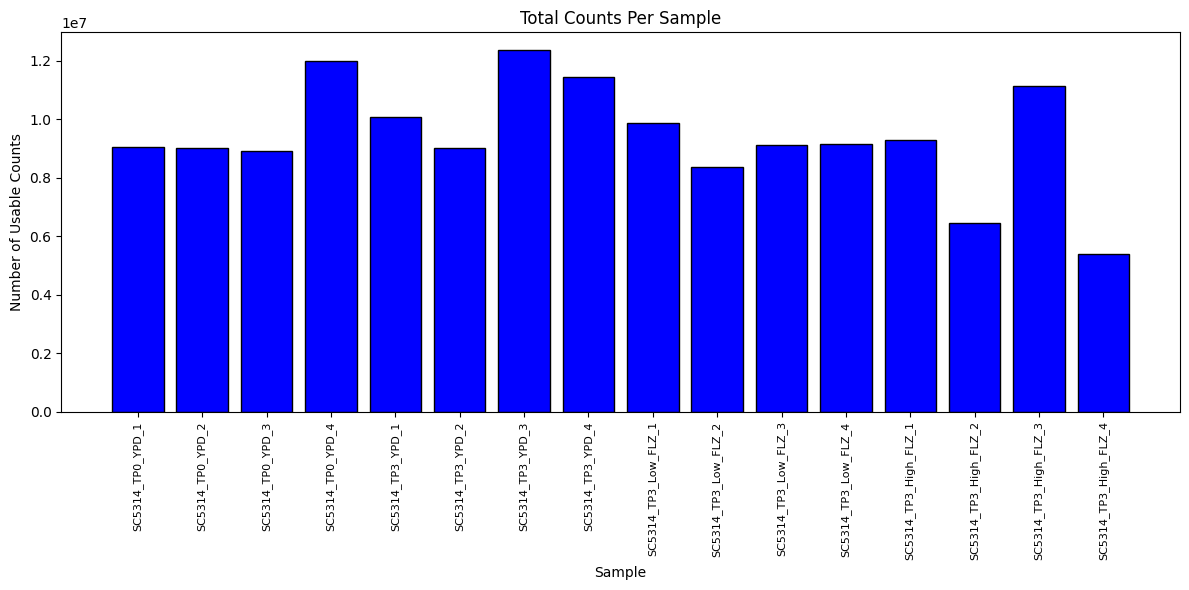

Text(0, 0.5, 'Number of usable counts')

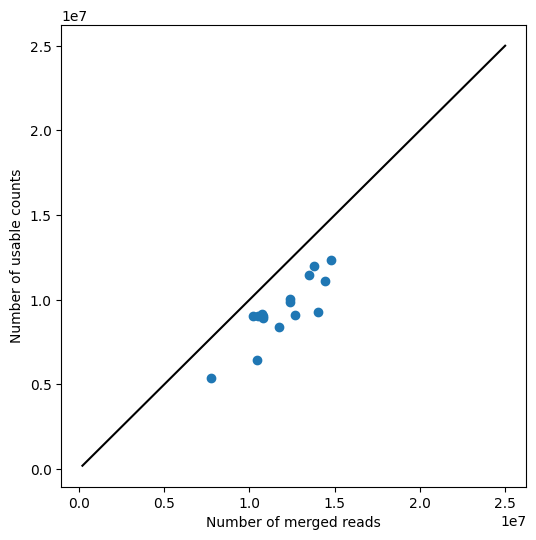

In [28]:
#Plotting the number of usable counts from each sample

#List of all sample columns
samples = [
    'SC5314_TP0_YPD_1', 'SC5314_TP0_YPD_2', 'SC5314_TP0_YPD_3', 'SC5314_TP0_YPD_4',
    'SC5314_TP3_YPD_1', 'SC5314_TP3_YPD_2', 'SC5314_TP3_YPD_3', 'SC5314_TP3_YPD_4',
    'SC5314_TP3_Low_FLZ_1', 'SC5314_TP3_Low_FLZ_2', 'SC5314_TP3_Low_FLZ_3', 'SC5314_TP3_Low_FLZ_4',
    'SC5314_TP3_High_FLZ_1', 'SC5314_TP3_High_FLZ_2', 'SC5314_TP3_High_FLZ_3', 'SC5314_TP3_High_FLZ_4'
]

#Calculate total counts for each sample (sum of sgRNA counts per sample)
sample_counts = sgRNA_df[samples].sum(axis=0)  # Sum across sgRNAs (rows) for each sample (columns)

#Plotting
plt.figure(figsize=(12, 6))
plt.bar(sample_counts.index, sample_counts.values, color='blue', edgecolor='black')

#Formatting the plot
plt.xticks(rotation=90, fontsize=8)
plt.title('Total Counts Per Sample')
plt.xlabel('Sample')
plt.ylabel('Number of Usable Counts')
plt.tight_layout()
plt.show()

#Plotting the number of usable counts vs. merged reads for each sample
plt.figure(figsize=(6,6))
plt.scatter(input_datasheet.assembled_reads, sample_counts)

plt.plot([200000, 25000000], [200000, 25000000], '-k')

plt.xlabel('Number of merged reads')
plt.ylabel('Number of usable counts')

In [29]:
#Load original file
sgRNA_df = pd.read_csv('../sgrna_list.csv')

#Create a copy for processing
sgRNA_df_no_NaN = sgRNA_df.copy()

#Define the count columns
count_col_list = [
    'SC5314_TP0_YPD_1', 'SC5314_TP0_YPD_2', 'SC5314_TP0_YPD_3', 'SC5314_TP0_YPD_4', 
    'SC5314_TP3_YPD_1', 'SC5314_TP3_YPD_2', 'SC5314_TP3_YPD_3', 'SC5314_TP3_YPD_4', 
    'SC5314_TP3_Low_FLZ_1', 'SC5314_TP3_Low_FLZ_2', 'SC5314_TP3_Low_FLZ_3', 'SC5314_TP3_Low_FLZ_4', 
    'SC5314_TP3_High_FLZ_1', 'SC5314_TP3_High_FLZ_2', 'SC5314_TP3_High_FLZ_3', 'SC5314_TP3_High_FLZ_4'
]

#Replace NaNs with 0
sgRNA_df_no_NaN[count_col_list] = sgRNA_df_no_NaN[count_col_list].fillna(0)

#Validate
print("NaN counts after replacement (should all be 0):")
print(sgRNA_df_no_NaN[count_col_list].isna().sum())

#Save processed version
sgRNA_df_no_NaN.to_csv('sgrna_list_no_NaN.csv', index=False)

NaN counts after replacement (should all be 0):
SC5314_TP0_YPD_1         0
SC5314_TP0_YPD_2         0
SC5314_TP0_YPD_3         0
SC5314_TP0_YPD_4         0
SC5314_TP3_YPD_1         0
SC5314_TP3_YPD_2         0
SC5314_TP3_YPD_3         0
SC5314_TP3_YPD_4         0
SC5314_TP3_Low_FLZ_1     0
SC5314_TP3_Low_FLZ_2     0
SC5314_TP3_Low_FLZ_3     0
SC5314_TP3_Low_FLZ_4     0
SC5314_TP3_High_FLZ_1    0
SC5314_TP3_High_FLZ_2    0
SC5314_TP3_High_FLZ_3    0
SC5314_TP3_High_FLZ_4    0
dtype: int64


In [30]:
#Show the current dataframe containing all of the information on sgRNAs and counts
sgRNA_df_no_NaN

,Number,Alias,Gene,Barcode,Position,SC5314_TP0_YPD_1,SC5314_TP0_YPD_2,SC5314_TP0_YPD_3,SC5314_TP0_YPD_4,SC5314_TP3_YPD_1,...,SC5314_TP3_YPD_3,SC5314_TP3_YPD_4,SC5314_TP3_Low_FLZ_1,SC5314_TP3_Low_FLZ_2,SC5314_TP3_Low_FLZ_3,SC5314_TP3_Low_FLZ_4,SC5314_TP3_High_FLZ_1,SC5314_TP3_High_FLZ_2,SC5314_TP3_High_FLZ_3,SC5314_TP3_High_FLZ_4
0,1,CR07390CA_242,CR07390C_A,TGCGCACAATTTCCTGCACA,1605752.0,1119.0,312.0,879.0,1900.0,0.0,...,0.0,87.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,CR07390CA_276_revcom,CR07390C_A,GAGTATAGTGATCCATGTGC,1605740.0,2017.0,1006.0,956.0,2949.0,344.0,...,472.0,459.0,303.0,598.0,1319.0,165.0,232.0,302.0,0.0,466.0
2,3,CR07390CA_239_revcom,CR07390C_A,GCTATAACGTTACTAGTAGT,1605777.0,88867.0,86080.0,83323.0,116333.0,94225.0,...,110503.0,107952.0,78991.0,66290.0,74728.0,75440.0,73300.0,50792.0,72423.0,40650.0
3,4,CR07390CA_140_revcom,CR07390C_A,ATAGATGTGATTGTCTTATA,1605876.0,1977.0,755.0,1625.0,3364.0,130.0,...,363.0,205.0,159.0,56.0,113.0,75.0,1.0,0.0,237.0,0.0
4,5,CR07390CA_212_revcom,CR07390C_A,TCCATCATCATTATTACAAT,1605804.0,1182.0,862.0,952.0,1604.0,1415.0,...,1441.0,1752.0,823.0,759.0,875.0,1034.0,2235.0,529.0,1748.0,486.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5696,5697,non-targeting57,non-targeting57,TCCCCAAGGCTGTCCCCCAA,NaN,1437.0,926.0,1189.0,1853.0,1421.0,...,951.0,1631.0,1507.0,757.0,248.0,1264.0,623.0,600.0,550.0,582.0
5697,5698,non-targeting58,non-targeting58,GACCTCTTTCGACTAGGCCA,NaN,733.0,341.0,341.0,1296.0,171.0,...,234.0,252.0,44.0,92.0,202.0,163.0,0.0,141.0,0.0,179.0
5698,5699,non-targeting59,non-targeting59,GCACTAGCGTCCCACGAATG,NaN,433.0,102.0,266.0,267.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,132.0,0.0,0.0,0.0
5699,5700,non-targeting60,non-targeting60,AGACTGAAACGGCAGCGCGA,NaN,1681.0,1459.0,1483.0,2815.0,745.0,...,2055.0,1670.0,726.0,1302.0,918.0,1407.0,653.0,1581.0,1212.0,783.0


In [33]:
#Load the sgRNA_df_no_NaN.csv file again in case you closed the program
sgRNA_df_no_NaN = pd.read_csv('./sgrna_list_no_NaN.csv', index_col=0)

In [34]:
#Confirm that the samples value from before contains all of the samples in your .csv file
samples

['SC5314_TP0_YPD_1',
 'SC5314_TP0_YPD_2',
 'SC5314_TP0_YPD_3',
 'SC5314_TP0_YPD_4',
 'SC5314_TP3_YPD_1',
 'SC5314_TP3_YPD_2',
 'SC5314_TP3_YPD_3',
 'SC5314_TP3_YPD_4',
 'SC5314_TP3_Low_FLZ_1',
 'SC5314_TP3_Low_FLZ_2',
 'SC5314_TP3_Low_FLZ_3',
 'SC5314_TP3_Low_FLZ_4',
 'SC5314_TP3_High_FLZ_1',
 'SC5314_TP3_High_FLZ_2',
 'SC5314_TP3_High_FLZ_3',
 'SC5314_TP3_High_FLZ_4']

## Calculate Frequencies from Raw Counts

We are ultimately going to filter out those gRNAs that do not meet a certain frequency threshold in a given sample. We do this rather than filtering out gRNAs that were not counted at least X number of times in a given sample, for example, as the total number of counts differs between different samples. So first we calculate the frequency of each gRNA in each sample.

Remember, we add the equivalent of one count to each gRNA in each sample to calculate the frequency value (otherwise you could not actually generate a frequency), so you will still see a lot of gRNAs with a "0" in the count, but its corresponding frequency will be a value that reflects the corresponding count if it had a single extra count added to it. 

In [47]:
frequencies_df = sgRNA_df_no_NaN
frequencies_df

,Alias,Gene,Barcode,Position,SC5314_TP0_YPD_1,SC5314_TP0_YPD_2,SC5314_TP0_YPD_3,SC5314_TP0_YPD_4,SC5314_TP3_YPD_1,SC5314_TP3_YPD_2,...,freq_SC5314_TP3_YPD_3,freq_SC5314_TP3_YPD_4,freq_SC5314_TP3_Low_FLZ_1,freq_SC5314_TP3_Low_FLZ_2,freq_SC5314_TP3_Low_FLZ_3,freq_SC5314_TP3_Low_FLZ_4,freq_SC5314_TP3_High_FLZ_1,freq_SC5314_TP3_High_FLZ_2,freq_SC5314_TP3_High_FLZ_3,freq_SC5314_TP3_High_FLZ_4
Number,,,,,,,,,,,,,,,,,,,,,
1,CR07390CA_242,CR07390C_A,TGCGCACAATTTCCTGCACA,1605752.0,1119.0,312.0,879.0,1900.0,0.0,0.0,...,8.094513e-08,7.687735e-06,1.011241e-07,1.192799e-07,1.097333e-07,1.094466e-07,1.076609e-07,1.552504e-07,8.991621e-08,1.858576e-07
2,CR07390CA_276_revcom,CR07390C_A,GAGTATAGTGATCCATGTGC,1605740.0,2017.0,1006.0,956.0,2949.0,344.0,811.0,...,3.828705e-05,4.018589e-05,3.074173e-05,7.144866e-05,1.448479e-04,1.816813e-05,2.508500e-05,4.704087e-05,8.991621e-08,8.679549e-05
3,CR07390CA_239_revcom,CR07390C_A,GCTATAACGTTACTAGTAGT,1605777.0,88867.0,86080.0,83323.0,116333.0,94225.0,81253.0,...,8.944761e-03,9.430842e-03,7.987996e-03,7.907184e-03,8.200259e-03,8.256760e-03,7.891655e-03,7.885633e-03,6.512092e-03,7.555296e-03
4,CR07390CA_140_revcom,CR07390C_A,ATAGATGTGATTGTCTTATA,1605876.0,1977.0,755.0,1625.0,3364.0,130.0,0.0,...,2.946403e-05,1.799629e-05,1.617986e-05,6.798954e-06,1.250959e-05,8.317941e-06,2.153219e-07,1.552504e-07,2.140006e-05,1.858576e-07
5,CR07390CA_212_revcom,CR07390C_A,TCCATCATCATTATTACAAT,1605804.0,1182.0,862.0,952.0,1604.0,1415.0,943.0,...,1.167229e-04,1.531432e-04,8.332627e-05,9.065273e-05,9.612636e-05,1.132772e-04,2.407299e-04,8.228270e-05,1.572635e-04,9.051264e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5697,non-targeting57,non-targeting57,TCCCCAAGGCTGTCCCCCAA,NaN,1437.0,926.0,1189.0,1853.0,1421.0,672.0,...,7.705977e-05,1.425725e-04,1.524952e-04,9.041417e-05,2.732359e-05,1.384499e-04,6.718043e-05,9.330548e-05,4.954383e-05,1.083550e-04
5698,non-targeting58,non-targeting58,GACCTCTTTCGACTAGGCCA,NaN,733.0,341.0,341.0,1296.0,171.0,574.0,...,1.902211e-05,2.210224e-05,4.550585e-06,1.109303e-05,2.227586e-05,1.794924e-05,1.076609e-07,2.204555e-05,8.991621e-08,3.345436e-05
5699,non-targeting59,non-targeting59,GCACTAGCGTCCCACGAATG,NaN,433.0,102.0,266.0,267.0,0.0,0.0,...,8.094513e-08,8.736063e-08,1.011241e-07,1.192799e-07,1.097333e-07,1.094466e-07,1.431891e-05,1.552504e-07,8.991621e-08,1.858576e-07


In [48]:
#Define the count columns again in case you closed the program
count_col_list = [
    'SC5314_TP0_YPD_1', 'SC5314_TP0_YPD_2', 'SC5314_TP0_YPD_3', 'SC5314_TP0_YPD_4', 
    'SC5314_TP3_YPD_1', 'SC5314_TP3_YPD_2', 'SC5314_TP3_YPD_3', 'SC5314_TP3_YPD_4', 
    'SC5314_TP3_Low_FLZ_1', 'SC5314_TP3_Low_FLZ_2', 'SC5314_TP3_Low_FLZ_3', 'SC5314_TP3_Low_FLZ_4', 
    'SC5314_TP3_High_FLZ_1', 'SC5314_TP3_High_FLZ_2', 'SC5314_TP3_High_FLZ_3', 'SC5314_TP3_High_FLZ_4'
]

freq_col_list = []

#Add pseudocount of 1 to all sgRNA counts
pseudocount = 1

#Note that the pseudocount of 1 is just added during calculation, the code does not update the original columns with an extra count. 
#So the original columns still have the real counts, the frequencies were just calculated with that extra pseudocount
for col in count_col_list:
    freq_col = 'freq_' + col
    #Add pseudocount to numerator AND account for total extra counts from pseudocounts in denominator
    frequencies_df[freq_col] = (frequencies_df[col] + pseudocount) / \
                               (frequencies_df[col].sum() + pseudocount * len(frequencies_df))
    freq_col_list.append(freq_col)

frequencies_df

,Alias,Gene,Barcode,Position,SC5314_TP0_YPD_1,SC5314_TP0_YPD_2,SC5314_TP0_YPD_3,SC5314_TP0_YPD_4,SC5314_TP3_YPD_1,SC5314_TP3_YPD_2,...,freq_SC5314_TP3_YPD_3,freq_SC5314_TP3_YPD_4,freq_SC5314_TP3_Low_FLZ_1,freq_SC5314_TP3_Low_FLZ_2,freq_SC5314_TP3_Low_FLZ_3,freq_SC5314_TP3_Low_FLZ_4,freq_SC5314_TP3_High_FLZ_1,freq_SC5314_TP3_High_FLZ_2,freq_SC5314_TP3_High_FLZ_3,freq_SC5314_TP3_High_FLZ_4
Number,,,,,,,,,,,,,,,,,,,,,
1,CR07390CA_242,CR07390C_A,TGCGCACAATTTCCTGCACA,1605752.0,1119.0,312.0,879.0,1900.0,0.0,0.0,...,8.094513e-08,7.687735e-06,1.011241e-07,1.192799e-07,1.097333e-07,1.094466e-07,1.076609e-07,1.552504e-07,8.991621e-08,1.858576e-07
2,CR07390CA_276_revcom,CR07390C_A,GAGTATAGTGATCCATGTGC,1605740.0,2017.0,1006.0,956.0,2949.0,344.0,811.0,...,3.828705e-05,4.018589e-05,3.074173e-05,7.144866e-05,1.448479e-04,1.816813e-05,2.508500e-05,4.704087e-05,8.991621e-08,8.679549e-05
3,CR07390CA_239_revcom,CR07390C_A,GCTATAACGTTACTAGTAGT,1605777.0,88867.0,86080.0,83323.0,116333.0,94225.0,81253.0,...,8.944761e-03,9.430842e-03,7.987996e-03,7.907184e-03,8.200259e-03,8.256760e-03,7.891655e-03,7.885633e-03,6.512092e-03,7.555296e-03
4,CR07390CA_140_revcom,CR07390C_A,ATAGATGTGATTGTCTTATA,1605876.0,1977.0,755.0,1625.0,3364.0,130.0,0.0,...,2.946403e-05,1.799629e-05,1.617986e-05,6.798954e-06,1.250959e-05,8.317941e-06,2.153219e-07,1.552504e-07,2.140006e-05,1.858576e-07
5,CR07390CA_212_revcom,CR07390C_A,TCCATCATCATTATTACAAT,1605804.0,1182.0,862.0,952.0,1604.0,1415.0,943.0,...,1.167229e-04,1.531432e-04,8.332627e-05,9.065273e-05,9.612636e-05,1.132772e-04,2.407299e-04,8.228270e-05,1.572635e-04,9.051264e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5697,non-targeting57,non-targeting57,TCCCCAAGGCTGTCCCCCAA,NaN,1437.0,926.0,1189.0,1853.0,1421.0,672.0,...,7.705977e-05,1.425725e-04,1.524952e-04,9.041417e-05,2.732359e-05,1.384499e-04,6.718043e-05,9.330548e-05,4.954383e-05,1.083550e-04
5698,non-targeting58,non-targeting58,GACCTCTTTCGACTAGGCCA,NaN,733.0,341.0,341.0,1296.0,171.0,574.0,...,1.902211e-05,2.210224e-05,4.550585e-06,1.109303e-05,2.227586e-05,1.794924e-05,1.076609e-07,2.204555e-05,8.991621e-08,3.345436e-05
5699,non-targeting59,non-targeting59,GCACTAGCGTCCCACGAATG,NaN,433.0,102.0,266.0,267.0,0.0,0.0,...,8.094513e-08,8.736063e-08,1.011241e-07,1.192799e-07,1.097333e-07,1.094466e-07,1.431891e-05,1.552504e-07,8.991621e-08,1.858576e-07


Text(0, 0.5, 'Freq')

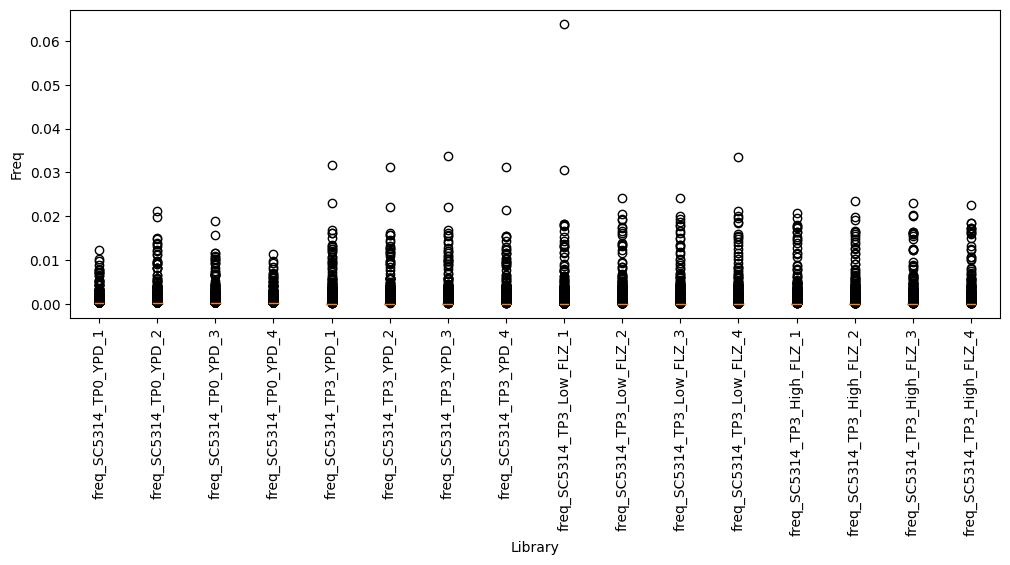

In [49]:
plt.figure(figsize=(12,4))

#Let's also look at the distribution of raw abundances for each library
x=0

for col in freq_col_list:
    #Print the number of reads for each library
    
    plt.boxplot(frequencies_df[col].dropna(), positions=[x])
    x+=1

plt.xticks(range(0, len(freq_col_list)), freq_col_list, rotation=90)
#Label x-ticks

plt.xlabel('Library')
plt.ylabel('Freq')
#Format axis labels

In [50]:
frequencies_df.to_csv("frequencies.csv")